In [1]:
from dxchange.reader import read_edf
import numpy as np
import matplotlib.pyplot as plt
from cil.io import TIFFStackReader
import os 
os.chdir('/zhome/71/c/146676/Desktop/msaca/main/')
import auxilliary_functions as af
import SimpleITK as sitk
from astropy.io import fits
import extended_data as ed
from cil.framework import AcquisitionGeometry, AcquisitionData, ImageGeometry, ImageData, BlockDataContainer
#import cor_tilt_corrector as ctc
import importlib
from cil.io import TIFFWriter

In [57]:
edf_path = '/dtu-compute/msaca/sliceA_xray_pc/HA900_3um_mars_rock_004_/'
name = 'HA900_3um_mars_rock_004_1991.edf'
dark1 = 'dark.edf'
dark2 = 'darkend0000.edf'
obeam = 'refHST6000.edf'
path_name = edf_path + name
path_name_dark = edf_path + dark1
path_name_obeam = edf_path + obeam

Description of the data:
There are 7 folder and 7 nx files (NeXus files). These can be opened in CIL but are 93.9 GB each, so wtch out for memory consumption.
Each folder contains 2 darks and2 flats, taken before or after the projections. There are 6000 projections. Of size 2048². The size of each file is 16MB and the type is uint32. One can likely compress the data to uint16. 


In [69]:
array = read_edf(path_name)
array_dark = read_edf(path_name_dark)
array_obeam = read_edf(path_name_obeam)

In [70]:
type(array)
print(np.shape(array_dark))
print(np.shape(array_obeam))


(1, 2048, 2048)
(1, 2048, 2048)


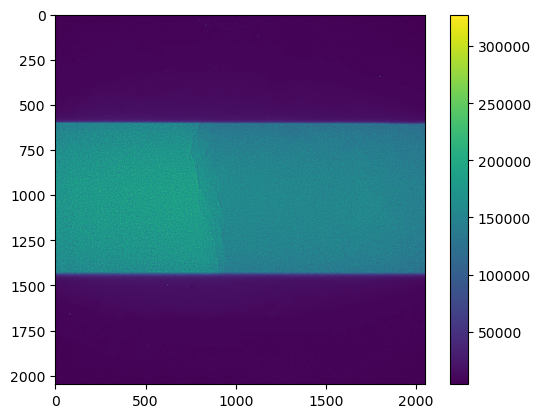

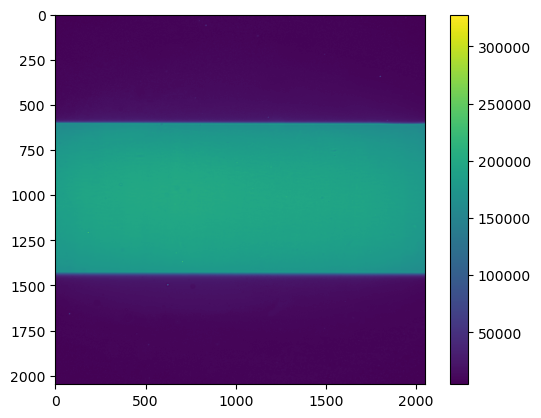

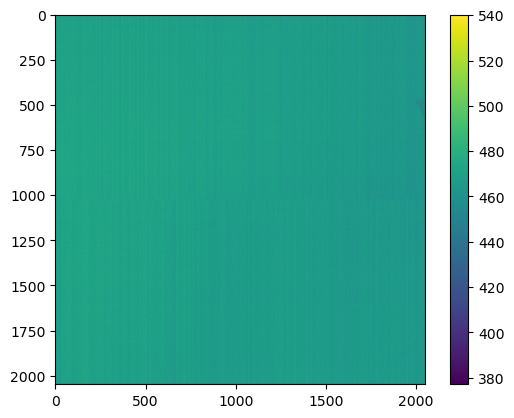

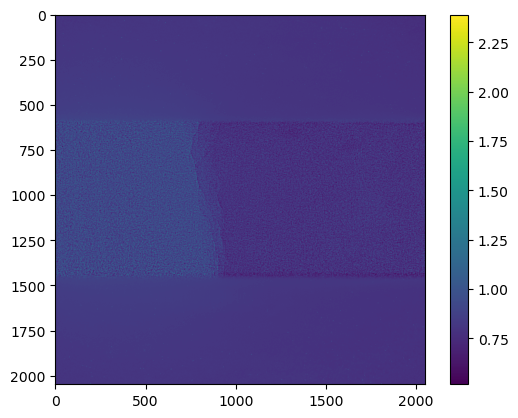

In [71]:
plt.imshow(array[0])
plt.colorbar()
plt.show()
plt.imshow(array_obeam[0])
plt.colorbar()
plt.show()
plt.imshow(array_dark[0])
plt.colorbar()
plt.show()

normalized = ((array - array_dark)/array_obeam)
plt.imshow(normalized[0])
plt.colorbar()
plt.show()

In [9]:
from PIL import Image
path = '/dtu-compute/msaca/sliceA_xray_pc/estrids_recon/xray_3um_reslice_itksnap.tif'
import SimpleITK as sitk

# Read the 3D TIFF file
tif_file = "path/to/your/file.tif"
img = sitk.ReadImage(path)

# Convert to a NumPy array if needed
img_array = sitk.GetArrayFromImage(img)
print(img_array.shape)  # Check the shape of the 3D array


TIFFReadDirectory: Warning, Unknown field with tag 50838 (0xc696) encountered.
TIFFReadDirectory: Warning, Unknown field with tag 50839 (0xc697) encountered.
TIFFReadDirectory: Warning, Unknown field with tag 50838 (0xc696) encountered.
TIFFReadDirectory: Warning, Unknown field with tag 50839 (0xc697) encountered.


(1412, 1392, 280)


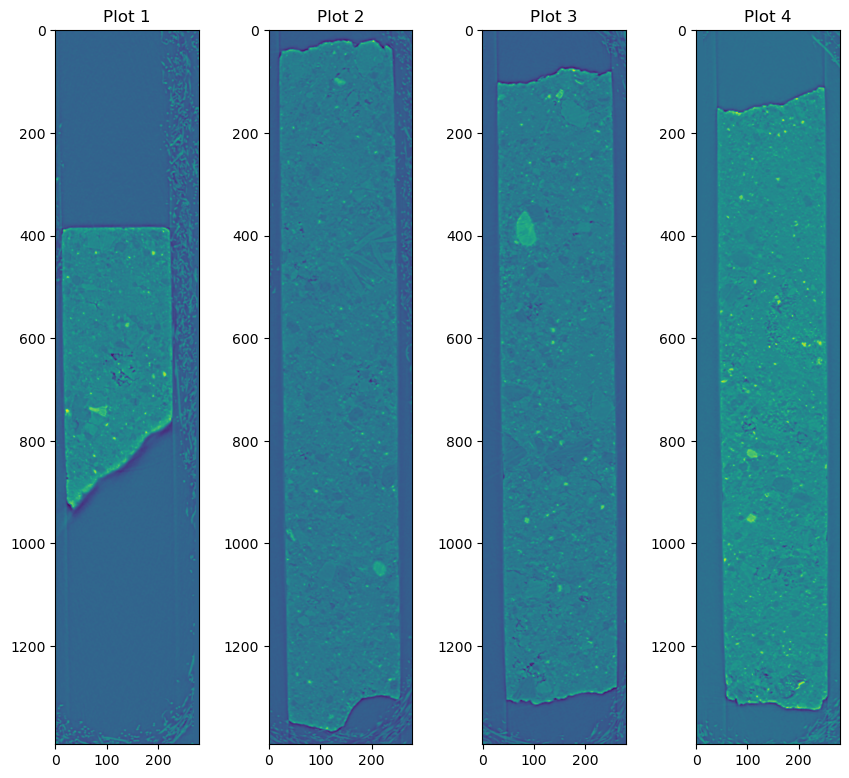

In [55]:
n_plots = 4
# Create a 1x4 grid for the subplots
fig, axes = plt.subplots(1, n_plots, figsize=(6, 2))

# Loop through the axes and plot on each subplot
for i, ax in enumerate(axes):
    ax.imshow(img_array[200+i*250])  # Example data
    ax.set_title(f'Plot {i+1}')

plt.tight_layout(pad=-20.1) 
plt.show()

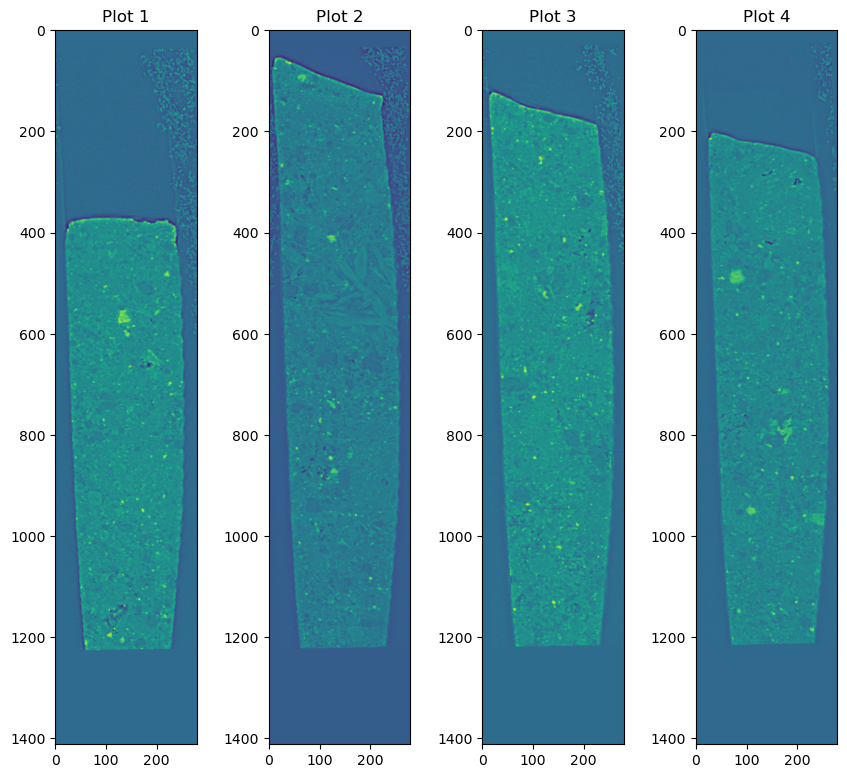

In [45]:
n_plots = 4
# Create a 1x4 grid for the subplots
fig, axes = plt.subplots(1, n_plots, figsize=(6, 2))

# Loop through the axes and plot on each subplot
for i, ax in enumerate(axes):
    ax.imshow(img_array[:,200+i*250])  # Example data
    ax.set_title(f'Plot {i+1}')

plt.tight_layout(pad=-20.1) 
plt.show()

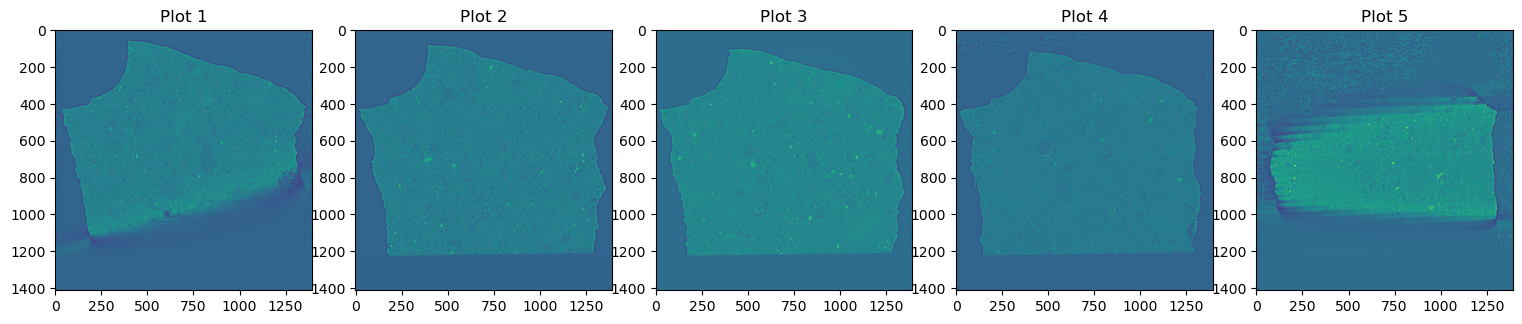

In [56]:
n_plots = 5
# Create a 1x4 grid for the subplots
fig, axes = plt.subplots(1, n_plots, figsize=(15, 5))

# Loop through the axes and plot on each subplot
for i, ax in enumerate(axes):
    ax.imshow(img_array[:,:,50+i*50])  # Example data
    ax.set_title(f'Plot {i+1}')

plt.tight_layout(pad=-0.1) 
plt.show()

In [ ]:
p_pre1 = '/dtu-compute/msaca/sliceA_xray_pc/HA900_3um_mars_rock_00'
p_pre2 = '_/HA900_3um_mars_rock_00'
p_post1 = '_####.edf'
p_post_dark = '_/dark.edf'
p_post_dark2 = '_/darkend0000.edf'
p_post_obeam = '_/refHST6000.edf'
stride = 25
A = range(1,6001, stride)
angles = np.linspace(0,360,len(A))
folders = [4]
start_crop = 620
end_crop = 1410
size_a = end_crop - start_crop
raw_data = np.empty((len(folders),len(A),size_a, 2048),dtype=np.float32)
raw_dark = np.empty((len(folders),size_a, 2048))
raw_obeam = np.empty((len(folders),size_a, 2048))
for i in range(len(folders)):
    edf_path = p_pre1 + str(folders[i]) + p_pre2 + str(folders[i]) + p_post1
    paths = af.generate_paths(edf_path, A)
    for idx in range(len(paths)):
        image = read_edf(paths[idx])
        image = np.squeeze(image)
        raw_data[i,idx] = image[start_crop:end_crop,:]

    edf_path_pre = '/dtu-compute/msaca/sliceA_xray_pc/HA900_3um_mars_rock_004_/'
    edf_path_dark = p_pre1 + str(folders[i]) + p_post_dark
    edf_path_obeam = p_pre1 + str(folders[i]) + p_post_obeam

    image_dark = read_edf(edf_path_dark)
    image_obeam = read_edf(edf_path_obeam)

    image_dark = np.squeeze(image_dark)
    image_obeam = np.squeeze(image_obeam)
    raw_dark[i] = image_dark[start_crop:end_crop,:]
    raw_obeam[i] = image_obeam[start_crop:end_crop,:]

raw_data = -np.log((raw_data - raw_dark[:, np.newaxis, :, :])/(raw_obeam[:, np.newaxis, :, :] - raw_dark[:, np.newaxis, :, :]))


    
overlap = 200
size_a_total = (size_a - overlap)*len(folders) + overlap
raw_data_concat = np.empty((len(A), size_a_total,2048))

end_index = overlap
print(size_a_total)
for i in range(len(folders)):
    start_index = end_index - overlap
    end_index = start_index + size_a

    print(start_index)
    print(end_index)

    raw_data_concat[:, start_index:end_index,:] = raw_data[i,:,:,:]


raw_data_concat = raw_data_concat[:,10:30]

OSError: File /dtu-compute/msaca/sliceA_xray_pc/HA900_3um_mars_rock_000_/dark.edf not found

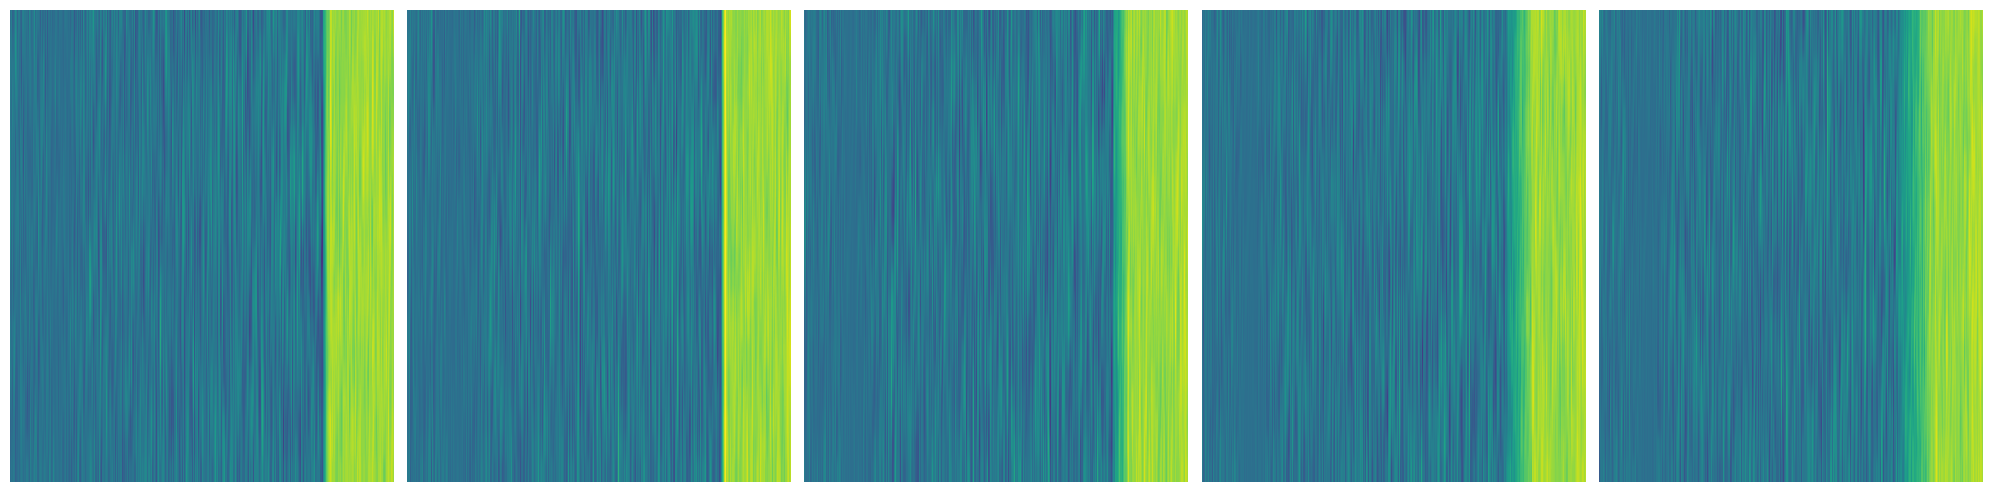

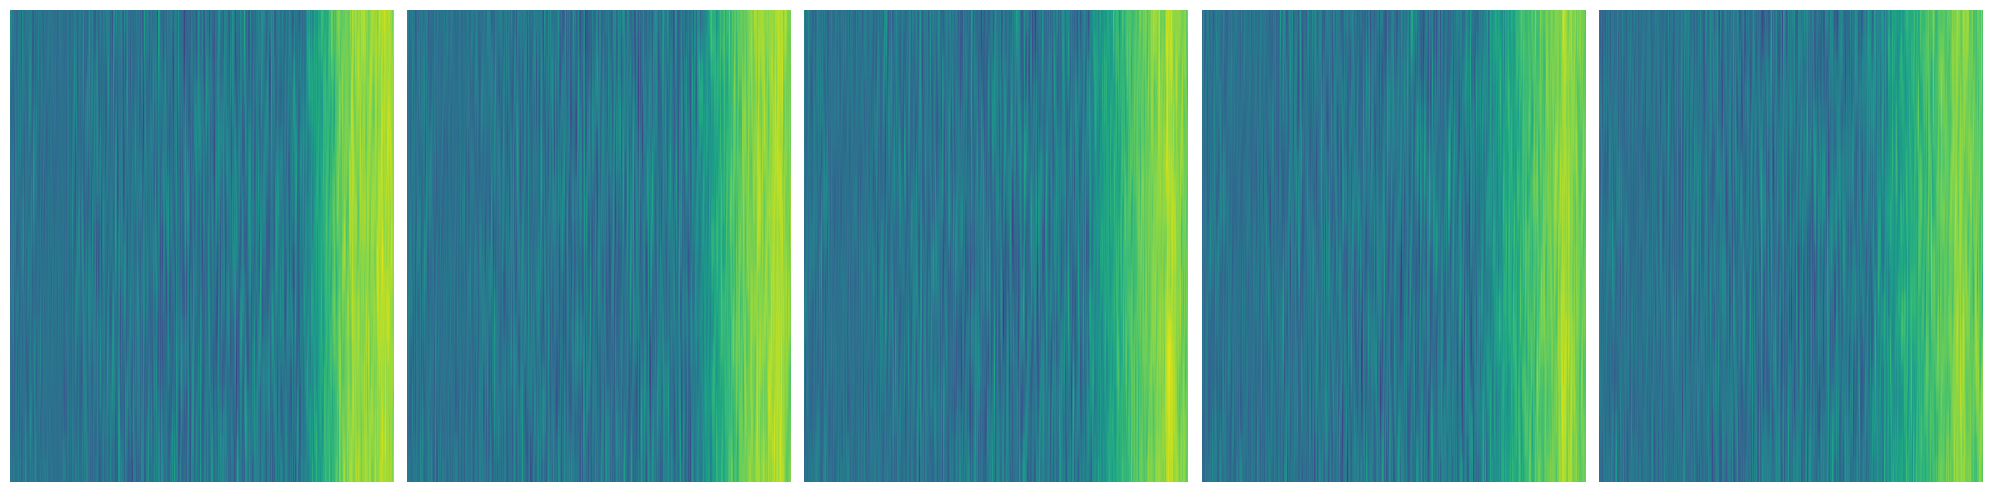

In [302]:
clims = [-0.5,1]

n_plots = 5
# Create a 1x4 grid for the subplots
fig, axes = plt.subplots(1, n_plots, figsize=(20, 5))

# Loop through the axes and plot on each subplot
for i, ax in enumerate(axes):
    ax.imshow(raw_data_concat[i,:,:], aspect='auto',vmin = clims[0], vmax = clims[1])  # Example data
    ax.axis('off')

plt.tight_layout(pad = +1) 
plt.show()

n_plots = 5
# Create a 1x4 grid for the subplots
fig, axes = plt.subplots(1, n_plots, figsize=(20, 5))

# Loop through the axes and plot on each subplot
for i, ax in enumerate(axes):
    ax.imshow(raw_data_concat[i+5,:,:], aspect='auto',vmin = clims[0], vmax = clims[1])  # Example data
    ax.axis('off')

plt.tight_layout(pad = +1) 
plt.show()

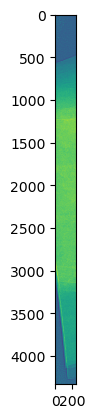

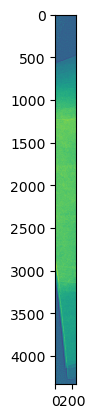

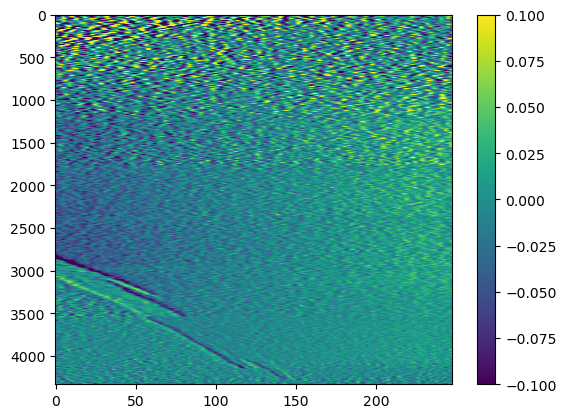

In [303]:

im1 = volume[index0,:,:]
im2 = np.flip(volume[index180,:,:],axis=1)
dist = 248
im1 = im1[:,-dist:]
im2 = im2[:,:dist]

plt.imshow(im1)
plt.show()
plt.imshow(im2)
plt.show()
plt.imshow(im1-im2,aspect='auto')
plt.colorbar()
plt.clim([-0.1,0.1])
plt.show()


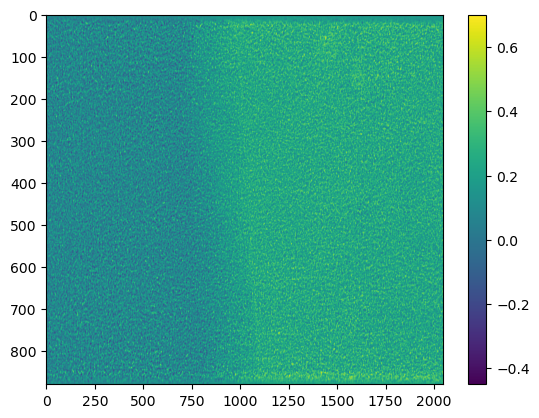

In [304]:
plt.imshow(data[10],aspect='auto')
plt.colorbar()
plt.show()

In [ ]:
import module_auxiliary as ma
importlib.reload(ma)
angles = np.linspace(0, 360, 6000, endpoint=True, dtype=np.float32)
angles = angles[::stride]
N_pixels = 2048
N_slices = np.shape(raw_data_concat)[1]
    
ag = AcquisitionGeometry.create_Parallel3D(detector_position=[0,N_pixels//2,0])\
                            .set_angles(angles)\
                            .set_panel((N_pixels+200,N_slices), pixel_size=(1,1))\
                            .set_labels(labels=('angle','vertical','horizontal'))

sinograms = ed.ExtendedData()
n1,n2,n3 = np.shape(raw_data_concat)
padded_raw_data = np.zeros((n1,n2,n3+200))
padded_raw_data[:,:,100:100+n3] = raw_data_concat
print(padded_raw_data[0,10,::50], len(raw_data_concat[0,10,::50]))
print(raw_data_concat[0,10,::50], len(padded_raw_data[0,10,::50]))

out_indices = []
for i in range(n1):
    out_indices.append([100, n3+100])
ma.gaussian_padding(padded_raw_data,out_indices, sigma = 30, cutoff=4, pad_mean_window_size = 40)

sinograms.set_data(data = padded_raw_data)
print(sinograms.data[0,10,::10])
print(sinograms.data[0,10,::10])
print(np.shape(sinograms.data))
sinograms.acquisition_data(geometry=ag)
sinograms.set_rotation_axis(position = [1024-124,0,0], rotation = [0,0,1])

[ 0.          0.          0.2384351  -0.05932601  0.03545897  0.15323368
  0.12003271  0.14092628  0.05706683  0.08087192  0.12423915  0.16985736
 -0.05722372  0.04895488  0.06368534  0.1141015   0.05270158  0.14401681
  0.08577555  0.02212552  0.12060891 -0.11043531 -0.12557813  0.02957508
  0.21383824  0.07636526  0.12396097  0.03918391  0.03220398  0.16186194
  0.19281935 -0.01532428  0.24349869 -0.11080871 -0.03330475  0.03107133
  0.70444143  0.78480596  0.68732336  0.6860308   0.79877488  0.71995454
  0.82264338  0.          0.        ] 41
[ 0.2384351  -0.05932601  0.03545897  0.15323368  0.12003271  0.14092628
  0.05706683  0.08087192  0.12423915  0.16985736 -0.05722372  0.04895488
  0.06368534  0.1141015   0.05270158  0.14401681  0.08577555  0.02212552
  0.12060891 -0.11043531 -0.12557813  0.02957508  0.21383824  0.07636526
  0.12396097  0.03918391  0.03220398  0.16186194  0.19281935 -0.01532428
  0.24349869 -0.11080871 -0.03330475  0.03107133  0.70444143  0.78480596
  0.687323

In [351]:
recon = sinograms.fbp()

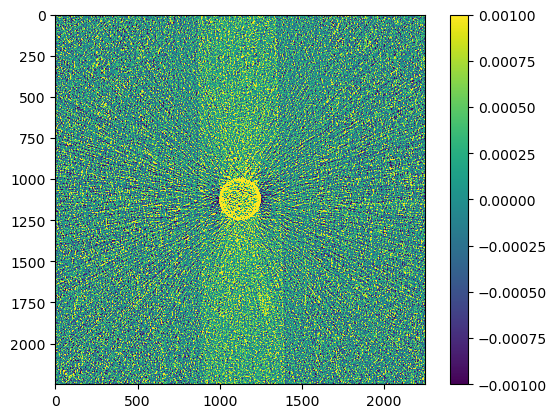

In [352]:
plt.imshow(recon.as_array()[10,:,:])
plt.clim([-0.001,0.001])
plt.colorbar()

In [1]:
import pyopencl as cl
import time
import numpy as np
import os 
os.chdir('/zhome/71/c/146676/Desktop/msaca/main/')

/zhome/71/c/146676/miniconda3/envs/cil5/lib/python3.10/site-packages/pytools/persistent_dict.py:52: RecommendedHashNotFoundWarning: Unable to import recommended hash 'siphash24.siphash13', falling back to 'hashlib.sha256'. Run 'python3 -m pip install siphash24' to install the recommended hash.
  warn("Unable to import recommended hash 'siphash24.siphash13', "


In [2]:
import add_arrays
o = add_arrays.add_arrays()


In [ ]:
k = int(1e+7)
x = np.ones(k, dtype=np.int32)
y = np.ones(k, dtype=np.int32)

start_time = time.time()
for i in range(100):
    # Code block to measure
    result = o.main(x)

end_time = time.time()
print(f"Execution time: {end_time - start_time:.6f} seconds")

AttributeError: 'add_arrays' object has no attribute 'indices_of_nonzero'

In [5]:
k = int(1e+7)
x = np.ones(k, dtype=np.int32)
y = np.ones(k, dtype=np.int32)
start_time = time.time()

# Code block to measure
for i in range(100):
    result = (x + y)*x + y

end_time = time.time()
print(f"Execution time: {end_time - start_time:.6f} seconds")

Execution time: 3.034892 seconds


In [29]:
import pyopencl as cl

try:
    platforms = cl.get_platforms()
    print("Available OpenCL platforms:", platforms)
except cl.LogicError:
    print("OpenCL is not installed or accessible.")

Available OpenCL platforms: [<pyopencl.Platform 'NVIDIA CUDA' at 0x557110f53750>]


In [10]:
import pyopencl as cl

platforms = cl.get_platforms()
print("Available platforms:")
for platform in platforms:
    print(f"- {platform.name}")

Available platforms:
- NVIDIA CUDA


In [11]:
import pyopencl as cl

platforms = cl.get_platforms()
for platform in platforms:
    print(f"Platform: {platform.name}")
    devices = platform.get_devices()
    for device in devices:
        print(f"  Device: {device.name}")


Platform: NVIDIA CUDA
  Device: NVIDIA A100-PCIE-40GB


In [12]:
platforms = cl.get_platforms()

# Find the NVIDIA CUDA platform
for platform in platforms:
    if "NVIDIA CUDA" in platform.name:
        devices = platform.get_devices()
        print(f"Using platform: {platform.name}")
        print(f"Devices: {[device.name for device in devices]}")

        # Create a context for the NVIDIA A100
        ctx = cl.Context(devices=devices)
        print("Context created successfully!")
        break
else:
    raise RuntimeError("NVIDIA CUDA platform not found.")

Using platform: NVIDIA CUDA
Devices: ['NVIDIA A100-PCIE-40GB']
Context created successfully!


In [13]:
array1_device = futhark_array.add_array(array1)
array2_device = futhark_array.add_array(array2)

NameError: name 'futhark_array' is not defined